In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df["Дата"] = pd.to_datetime(df["Дата"])

Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby("Дата")["Количество"].sum()

Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Нарисуйте график продаж у `grouped_df`

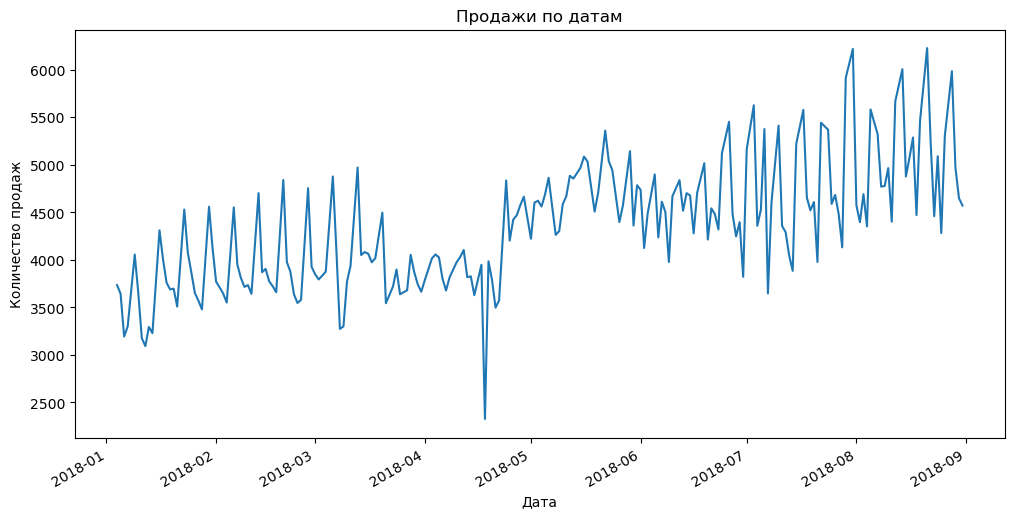

In [7]:
plt.figure(figsize=(12,6))
grouped_df.plot()

plt.title("Продажи по датам")
plt.xlabel("Дата")
plt.ylabel("Количество продаж")

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
На графике показана динамика количества продаж по датам.
В начале периода (январь-февраль) продажи находятся примерно в диапазоне 3200-4200 единиц.
А также наблюдаются регулярные колебания значений, что может указывать на сезонность 
или различия продаж по дням недели.
Начиная с мая-июня заметен общий рост продаж: средний уровень увеличивается примерно 
до 4500-5500 единиц.
В июле-августе наблюдается более высокие пики, достигающие примерно 6000-6200 продаж.
Также на графике присутствуется резкий спад примерно в апреле, который можно рассматривать 
более как выброс или аномальное значение. В целом тренд графика показывает постепенный 
рост продаж со временем при сохранении регулярных колебаний.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
df.loc[df["Количество"].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [9]:
df["weekday"] = df["Дата"].dt.weekday
df["month"] = df["Дата"].dt.month

In [11]:
filtered.groupby("Номенклатура")["Количество"].sum().sort_values(ascending=False).head(1)

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [69]:
import pandas as pd

weather = pd.read_csv(
    "astana_weather3.csv",
    encoding="cp1251",
    sep=";",          # у rp5 чаще ;
    comment="#",      # пропустить строки с #
    engine="python",
)

weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3,12.0,NaN,NaN,NaN,NaN


In [70]:
weather["Дата"] = pd.to_datetime(
    weather["Местное время в Астане"],
    dayfirst=True
)

In [71]:
weather["T"] = pd.to_numeric(weather["T"], errors="coerce")

In [74]:
weather["Дата"] = pd.to_datetime(
    weather["Местное время в Астане"],
    dayfirst=True
)

weather["T"] = pd.to_numeric(weather["T"], errors="coerce")

weather_daily = weather.groupby(weather["Дата"].dt.date)["T"].mean().reset_index()

weather_daily.columns = ["Дата","T"]

weather_daily.head()

,Дата,T
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625


In [75]:
sales = grouped_df.reset_index()

sales.columns = ["Дата","Количество продаж"]

sales["Дата"] = pd.to_datetime(sales["Дата"]).dt.date

In [76]:
merged = pd.merge(sales, weather_daily, on="Дата")

merged.head()

,Дата,Количество продаж,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


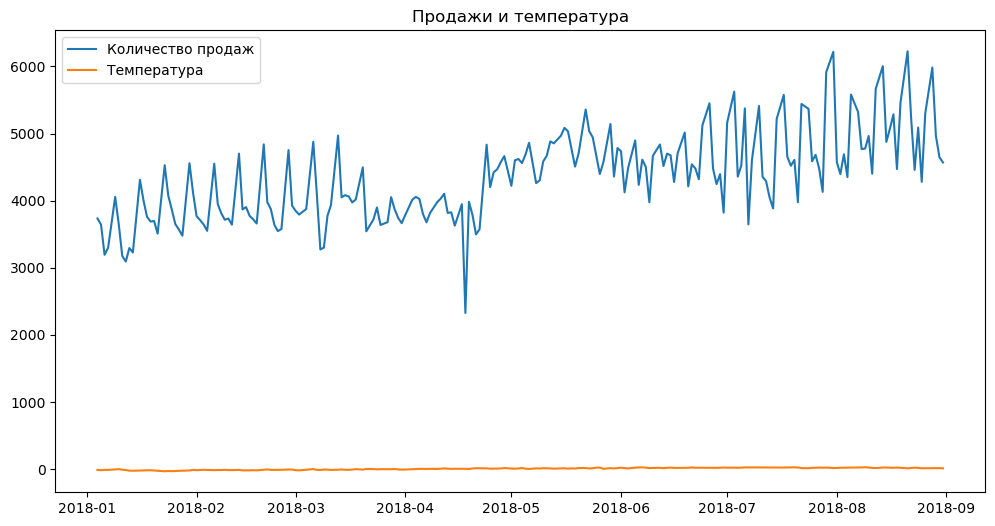

In [77]:
import matplotlib.pyplot as plt

merged["Дата"] = pd.to_datetime(merged["Дата"])

plt.figure(figsize=(12,6))

plt.plot(merged["Дата"], merged["Количество продаж"], label="Количество продаж")
plt.plot(merged["Дата"], merged["T"], label="Температура")

plt.legend()
plt.title("Продажи и температура")

plt.show()

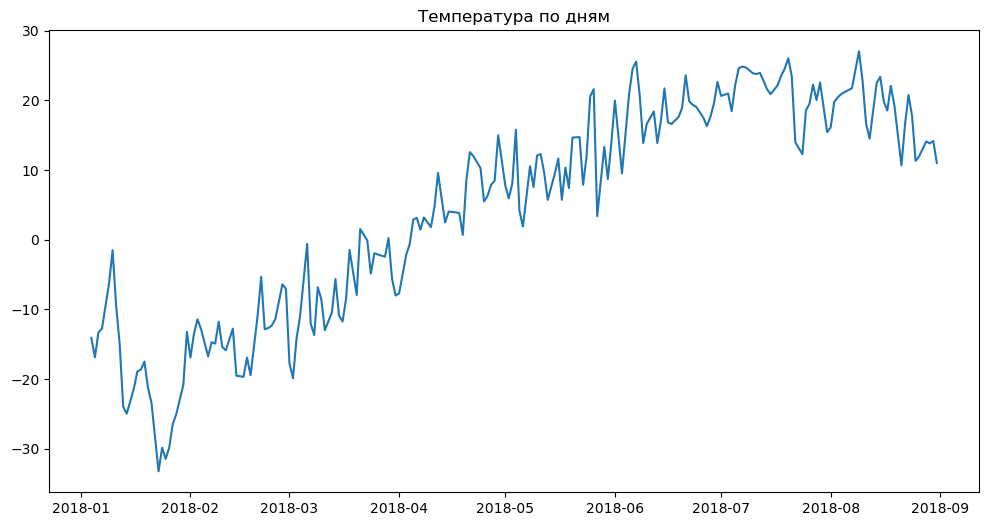

In [78]:
plt.figure(figsize=(12,6))

plt.plot(merged["Дата"], merged["T"])

plt.title("Температура по дням")

plt.show()